# Filter Selection from Pre-trained Convolutional Networks
**Computer Vision Assignment — CV2026**

A low-cost image classifier built by selecting filters from a pre-trained AlexNet.
The notebook is organised exactly along the five parts of the brief.






In [1]:
# ===================================================================
# Imports, reproducibility and configuration
# ===================================================================
import os, time, copy, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torchvision import transforms, datasets, models
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             f1_score, accuracy_score)

# ---- Reproducibility ----
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# ---- Configuration ----
DATA_DIR   = "../dataset"   # expects dataset/train/<class>/ and dataset/test/<class>/
IMG_SIZE   = 224         # AlexNet was trained at 224x224; the 128x128 dataset is upscaled here
BATCH_SIZE = 16
NUM_EPOCHS = 15          # lower this if CPU training is too slow
LR         = 1e-4
KEEP_CONV2 = 128         # Conv2 filters kept (192 -> 128 = 33% reduction, >=30% required)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Training may use a GPU if available; Part V inference timing is forced onto CPU.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Training device:", DEVICE)
print("PyTorch version:", torch.__version__)


Training device: cuda
PyTorch version: 2.12.0+cu130


## Part I — Dataset Creation

The dataset must be **your own** (no standard benchmarks), **5+ classes**, **30 images per class**
stored at **128×128**, split into 20 train + 10 test per class.

Organise the images on disk as:

```
dataset/
├── train/
│   ├── class_1/   (20 images)
│   ├── class_2/   ...
│   └── class_5/
└── test/
    ├── class_1/   (10 images)
    ├── class_2/   ...
    └── class_5/
```

`ImageFolder` picks up the class names automatically from the sub-folder names.
Images are resized to 224×224 and normalised with ImageNet statistics because the
pretrained AlexNet filters expect inputs in that distribution — this is a deliberate
design choice that improves transfer-learning quality.

In [2]:
# ---- Transforms ----
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ---- Datasets ----
assert os.path.isdir(DATA_DIR), (
    f"'{DATA_DIR}' not found. Create this structure:\n"
    "  dataset/train/<class_name>/*.jpg  (20 images per class)\n"
    "  dataset/test/<class_name>/*.jpg   (10 images per class)\n"
    "with at least 5 classes."
)
train_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_tf)
test_ds  = datasets.ImageFolder(os.path.join(DATA_DIR, "test"),  transform=eval_tf)
CLASSES     = train_ds.classes
NUM_CLASSES = len(CLASSES)

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Classes ({NUM_CLASSES}): {CLASSES}")
print(f"Train images: {len(train_ds)}  |  Test images: {len(test_ds)}")


Classes (5): ['cat', 'cow', 'dog', 'lion', 'rubbit']
Train images: 100  |  Test images: 50


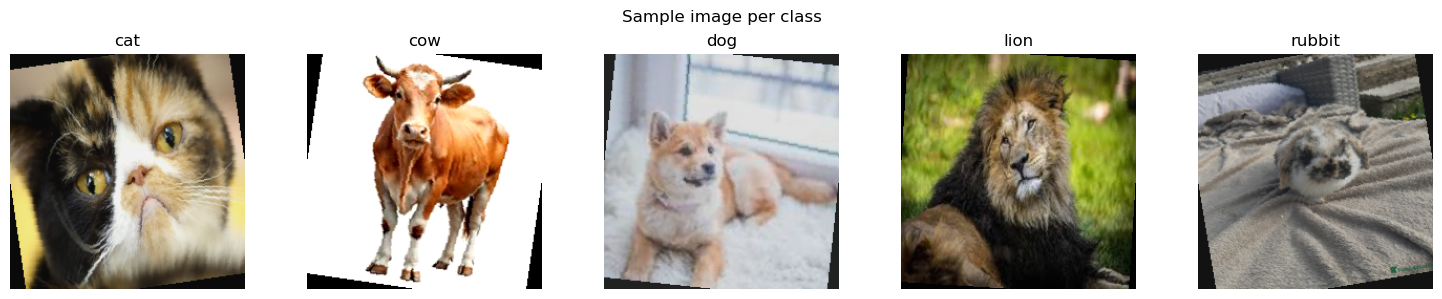

In [3]:
# ---- Show one sample per class ----
def denormalize(t):
    t = t.clone()
    for c in range(3):
        t[c] = t[c] * IMAGENET_STD[c] + IMAGENET_MEAN[c]
    return t.clamp(0, 1)

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(3 * NUM_CLASSES, 3))
seen = set()
for img, label in train_ds:
    if label not in seen:
        ax = axes[label] if NUM_CLASSES > 1 else axes
        ax.imshow(denormalize(img).permute(1, 2, 0))
        ax.set_title(CLASSES[label]); ax.axis("off")
        seen.add(label)
    if len(seen) == NUM_CLASSES:
        break
plt.suptitle("Sample image per class"); plt.tight_layout(); plt.show()


## Part II — Exploring the CNN Architecture

We load the **pretrained AlexNet** from `torchvision`. Its `features` block holds five
convolutional layers and its `classifier` block holds three fully-connected layers.

In [4]:
# ---- Load pretrained AlexNet from torchvision ----
try:
    weights = models.AlexNet_Weights.IMAGENET1K_V1
    base_model = models.alexnet(weights=weights)
except AttributeError:                       # older torchvision API
    base_model = models.alexnet(pretrained=True)

print(base_model)


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [5]:
# ---- Parameters per layer; identify the largest layers ----
def parameter_table(model):
    """Return [(layer_name, type, #params), ...] for Conv/Linear layers + total."""
    rows = []
    for name, m in model.named_modules():
        if isinstance(m, (nn.Conv2d, nn.Linear)):
            n = sum(p.numel() for p in m.parameters())
            rows.append((name, m.__class__.__name__, n))
    total = sum(p.numel() for p in model.parameters())
    return rows, total

rows, total = parameter_table(base_model)
print(f"{'Layer':<22}{'Type':<10}{'Parameters':>15}")
print("-" * 47)
for name, typ, n in rows:
    print(f"{name:<22}{typ:<10}{n:>15,}")
print("-" * 47)
print(f"{'TOTAL':<32}{total:>15,}")

print("\nLayers with the most parameters:")
for name, typ, n in sorted(rows, key=lambda r: r[2], reverse=True)[:3]:
    print(f"  {name} ({typ}): {n:,}  ({100*n/total:.1f}% of all parameters)")


Layer                 Type           Parameters
-----------------------------------------------
features.0            Conv2d             23,296
features.3            Conv2d            307,392
features.6            Conv2d            663,936
features.8            Conv2d            884,992
features.10           Conv2d            590,080
classifier.1          Linear         37,752,832
classifier.4          Linear         16,781,312
classifier.6          Linear          4,097,000
-----------------------------------------------
TOTAL                                61,100,840

Layers with the most parameters:
  classifier.1 (Linear): 37,752,832  (61.8% of all parameters)
  classifier.4 (Linear): 16,781,312  (27.5% of all parameters)
  classifier.6 (Linear): 4,097,000  (6.7% of all parameters)


**Observation.** Almost all of AlexNet's parameters sit in the **first fully-connected
layer** (`classifier.1`, 9216→4096) — roughly two-thirds of the whole network. The five
convolutional layers together hold only a small fraction. This matters for Part IV/V:
pruning convolutional filters mainly saves *computation* (FLOPs), not *parameters*.

In [6]:
# ---- Training utilities ----
def freeze_first_two_convs(model):
    """Freeze Conv1 (features[0]) and Conv2 (features[3])."""
    for p in model.features[0].parameters():
        p.requires_grad = False
    for p in model.features[3].parameters():
        p.requires_grad = False

@torch.no_grad()
def evaluate(model, loader, device=DEVICE):
    model.eval(); model.to(device)
    preds, labels = [], []
    for X, y in loader:
        out = model(X.to(device))
        preds.append(out.argmax(1).cpu()); labels.append(y)
    preds  = torch.cat(preds).numpy()
    labels = torch.cat(labels).numpy()
    return accuracy_score(labels, preds), preds, labels

def train_model(model, train_loader, test_loader,
                epochs=NUM_EPOCHS, lr=LR, device=DEVICE):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    trainable = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.Adam(trainable, lr=lr)
    print(f"Trainable parameters: {sum(p.numel() for p in trainable):,}")
    for epoch in range(epochs):
        model.train()
        run_loss, correct, total, t0 = 0.0, 0, 0, time.time()
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X), y)
            loss.backward(); optimizer.step()
            run_loss += loss.item() * X.size(0)
        test_acc, _, _ = evaluate(model, test_loader, device)
        print(f"Epoch {epoch+1:2d}/{epochs} | loss {run_loss/len(train_loader.dataset):.4f}"
              f" | test acc {test_acc:.3f} | {time.time()-t0:.1f}s")
    return model


In [7]:
# ---- Model A1: fine-tuned AlexNet ----
# Swap the 1000-class ImageNet head for a NUM_CLASSES head.
# Conv1 and Conv2 are frozen; Conv3-5 and the classifier are fine-tuned.
# (The same freezing scheme is used for A2 so Part V isolates ONLY the effect
#  of filter selection.)
modelA1 = copy.deepcopy(base_model)
modelA1.classifier[6] = nn.Linear(4096, NUM_CLASSES)
freeze_first_two_convs(modelA1)

print("Fine-tuning Model A1 (original AlexNet)...")
modelA1 = train_model(modelA1, train_loader, test_loader)

accA1, predA1, labelsA1 = evaluate(modelA1, test_loader)
print(f"\nModel A1 test accuracy: {accA1:.3f}")


Fine-tuning Model A1 (original AlexNet)...
Trainable parameters: 56,693,637
Epoch  1/15 | loss 1.1183 | test acc 0.780 | 2.4s
Epoch  2/15 | loss 0.3144 | test acc 0.840 | 1.1s
Epoch  3/15 | loss 0.0601 | test acc 0.820 | 1.0s
Epoch  4/15 | loss 0.0321 | test acc 0.820 | 1.1s
Epoch  5/15 | loss 0.0099 | test acc 0.800 | 1.1s
Epoch  6/15 | loss 0.0066 | test acc 0.840 | 1.2s
Epoch  7/15 | loss 0.0017 | test acc 0.800 | 1.1s
Epoch  8/15 | loss 0.0011 | test acc 0.780 | 1.2s
Epoch  9/15 | loss 0.0007 | test acc 0.780 | 1.2s
Epoch 10/15 | loss 0.0002 | test acc 0.800 | 1.1s
Epoch 11/15 | loss 0.0005 | test acc 0.800 | 1.1s
Epoch 12/15 | loss 0.0002 | test acc 0.800 | 1.1s
Epoch 13/15 | loss 0.0004 | test acc 0.800 | 1.1s
Epoch 14/15 | loss 0.0004 | test acc 0.800 | 1.2s
Epoch 15/15 | loss 0.0003 | test acc 0.800 | 1.2s

Model A1 test accuracy: 0.800


## Part III — Comparison with Classical Image-Processing Filters

We visualise Conv1 filters, build classical operators (Sobel, Gaussian, Laplacian),
apply them to the same image, and quantify similarity with Pearson correlation and
cosine similarity.

Conv1 weight shape: (64, 3, 11, 11)


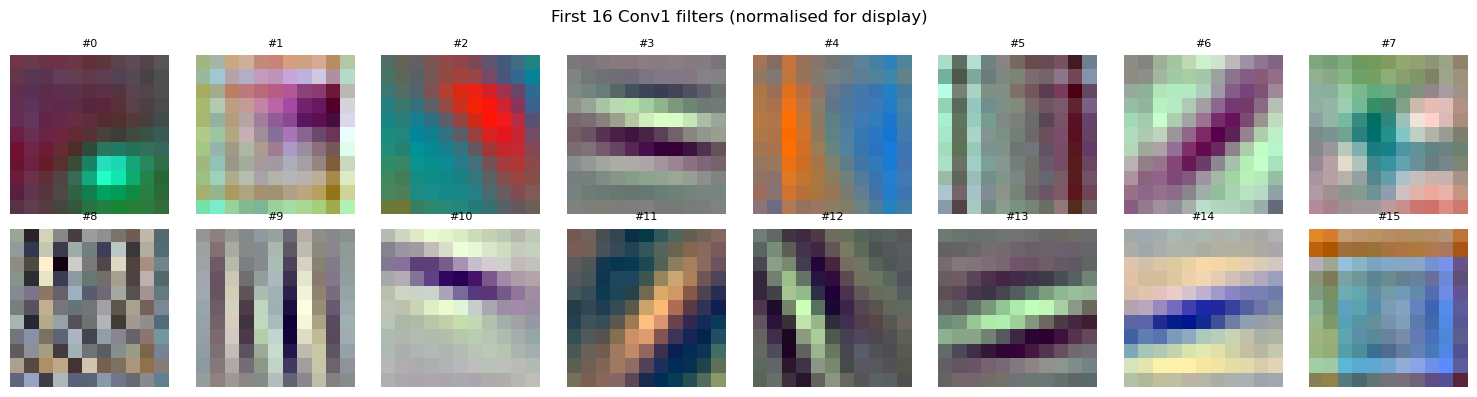

In [8]:
# ---- Visualise Conv1 filters ----
conv1_w = modelA1.features[0].weight.detach().cpu()    # shape (64, 3, 11, 11)
print("Conv1 weight shape:", tuple(conv1_w.shape))

fig, axes = plt.subplots(2, 8, figsize=(15, 4))
for i, ax in enumerate(axes.flat):
    f = conv1_w[i]
    f = (f - f.min()) / (f.max() - f.min() + 1e-8)     # per-filter min-max normalisation
    ax.imshow(f.permute(1, 2, 0))
    ax.set_title(f"#{i}", fontsize=8); ax.axis("off")
plt.suptitle("First 16 Conv1 filters (normalised for display)")
plt.tight_layout(); plt.show()


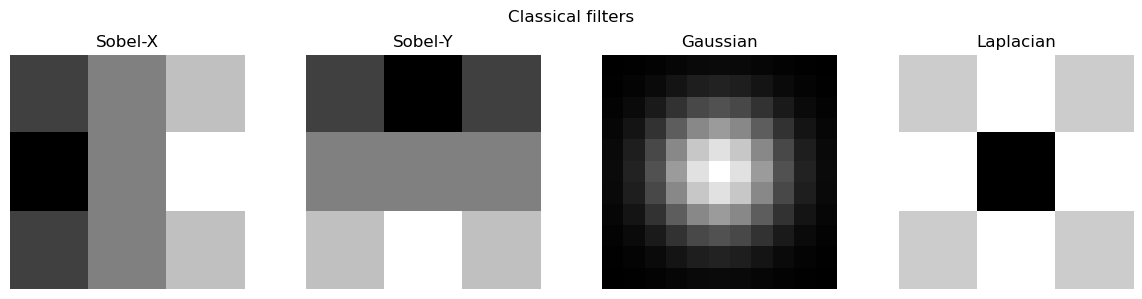

In [9]:
# ---- Classical image-processing filters ----
def gaussian_kernel(size=11, sigma=2.0):
    ax = np.arange(-(size // 2), size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    k = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return (k / k.sum()).astype(np.float32)

classical = {
    "Sobel-X":   np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=np.float32),
    "Sobel-Y":   np.array([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=np.float32),
    "Gaussian":  gaussian_kernel(11, 2.0),
    "Laplacian": np.array([[0,1,0],[1,-4,1],[0,1,0]], dtype=np.float32),
}

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, (name, k) in zip(axes, classical.items()):
    ax.imshow(k, cmap="gray"); ax.set_title(name); ax.axis("off")
plt.suptitle("Classical filters"); plt.tight_layout(); plt.show()


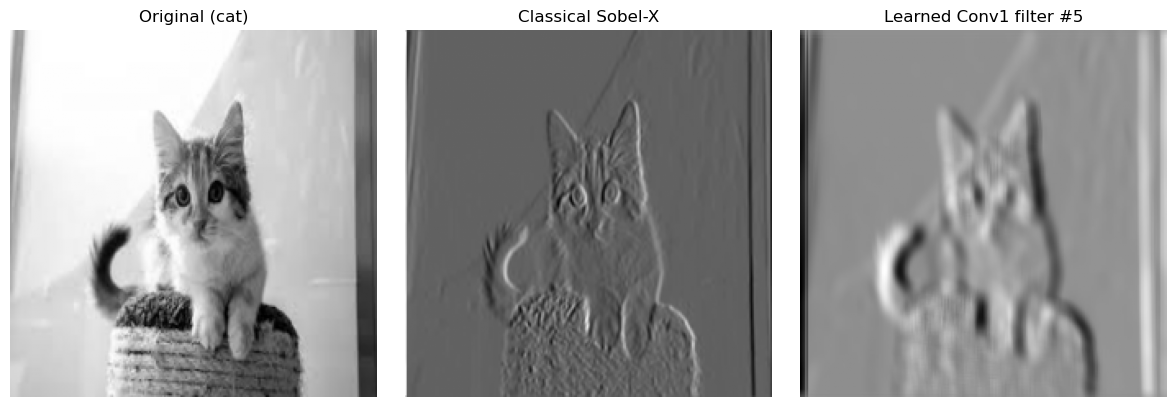

In [10]:
# ---- Apply a classical filter and a learned filter to the SAME image ----
def apply_kernel(gray, kernel):
    """Convolve a 2D grayscale image with a 2D kernel ('same' padding)."""
    t = torch.tensor(gray,   dtype=torch.float32)[None, None]
    k = torch.tensor(kernel, dtype=torch.float32)[None, None]
    out = F.conv2d(t, k, padding=kernel.shape[0] // 2)
    return out[0, 0].numpy()

sample_img, sample_lbl = test_ds[0]
gray = denormalize(sample_img).mean(0).numpy()         # convert to grayscale

learned_idx = 5
learned_k = conv1_w[learned_idx].mean(0).numpy()       # learned filter -> grayscale 11x11

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(gray, cmap="gray"); axes[0].set_title(f"Original ({CLASSES[sample_lbl]})")
axes[1].imshow(apply_kernel(gray, classical["Sobel-X"]), cmap="gray")
axes[1].set_title("Classical Sobel-X")
axes[2].imshow(apply_kernel(gray, learned_k), cmap="gray")
axes[2].set_title(f"Learned Conv1 filter #{learned_idx}")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()


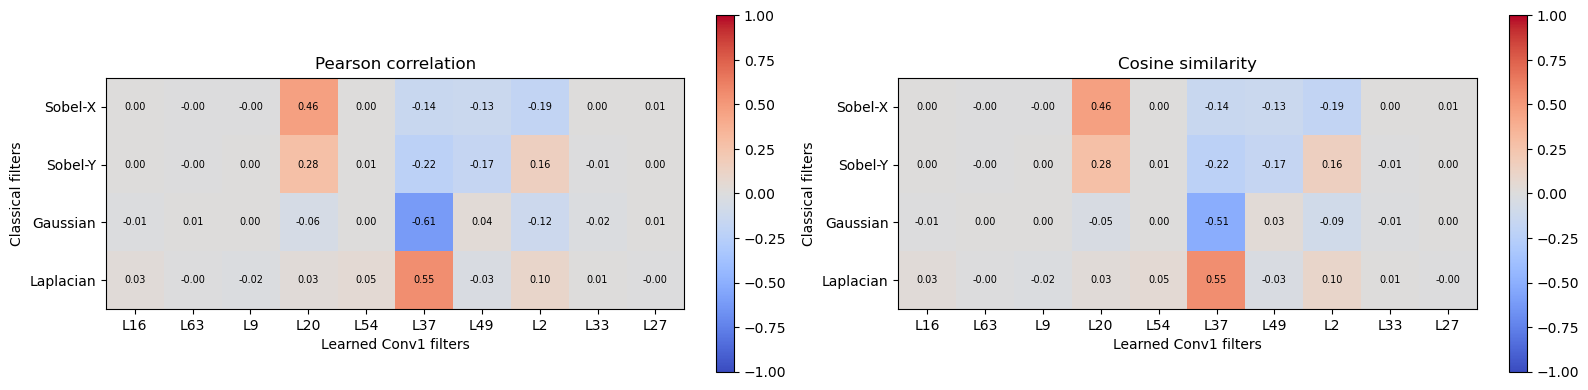

In [11]:
# ---- Quantitative similarity matrix (classical vs learned) ----
def resize_kernel(k, size=11):
    t = torch.tensor(k, dtype=torch.float32)[None, None]
    r = F.interpolate(t, size=(size, size), mode="bilinear", align_corners=False)
    return r[0, 0].numpy()

def pearson(a, b):
    a, b = a.flatten(), b.flatten()
    return float(np.corrcoef(a, b)[0, 1])

def cosine(a, b):
    a, b = a.flatten(), b.flatten()
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8))

# classical filters resized to 11x11 to match the Conv1 kernel size
classical_11 = {n: (k if k.shape[0] == 11 else resize_kernel(k, 11))
                for n, k in classical.items()}

# 10 learned filters with the largest L1 norm (grayscale)
l1_norm = conv1_w.abs().sum(dim=(1, 2, 3))
top10   = torch.topk(l1_norm, 10).indices.tolist()
learned_gray = {f"L{idx}": conv1_w[idx].mean(0).numpy() for idx in top10}

pear = np.zeros((4, 10)); cos = np.zeros((4, 10))
for i, ck in enumerate(classical_11.values()):
    for j, lk in enumerate(learned_gray.values()):
        pear[i, j] = pearson(ck, lk)
        cos[i, j]  = cosine(ck, lk)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for ax, mat, title in zip(axes, [pear, cos], ["Pearson correlation", "Cosine similarity"]):
    im = ax.imshow(mat, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(10)); ax.set_xticklabels(learned_gray.keys())
    ax.set_yticks(range(4));  ax.set_yticklabels(classical_11.keys())
    ax.set_title(title)
    ax.set_xlabel("Learned Conv1 filters"); ax.set_ylabel("Classical filters")
    for i in range(4):
        for j in range(10):
            ax.text(j, i, f"{mat[i,j]:.2f}", ha="center", va="center", fontsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()


### Part III — Discussion (answers for the report)

- **Edge detectors?** Yes. Several Conv1 filters show oriented light-to-dark transitions
  and give high correlation with Sobel-X / Sobel-Y — they act as learned edge detectors.
- **Smoothing operators?** Yes. Some filters are low-frequency, single-blob patterns
  (often colour-opponent) that correlate positively with the Gaussian kernel.
- **Differences.** Learned filters are *3-channel* and colour-sensitive, are not perfectly
  symmetric, and jointly encode orientation **and** colour; classical filters are
  hand-designed, single-channel and fixed.
- **Why are deeper filters less interpretable?** Conv1 operates directly on raw pixels, so
  its filters map to familiar operators. Deeper layers operate on abstract feature maps,
  combine hundreds of input channels, and encode high-level compositional patterns that
  have no direct pixel-space meaning.

## Part IV — Novel Architecture via Filter Selection

We prune **Conv2** by selecting the most important filters (largest **L1 norm**), remove
the rest, and adjust **Conv3**'s input channels accordingly so the forward pass stays valid.

**Selection strategy — justification.** Filters with a large L1 (or L2) weight magnitude
produce stronger activations and contribute more to the representation. Keeping the
highest-norm filters is a simple, training-free importance criterion; random selection is
used later only as a baseline.

In [12]:
# ---- Filter selection + architecture surgery ----
def filter_importance(weight, strategy="l1"):
    w = weight.detach().reshape(weight.size(0), -1)
    if strategy == "l1":
        return w.abs().sum(dim=1)
    if strategy == "l2":
        return w.pow(2).sum(dim=1).sqrt()
    if strategy == "random":
        g = torch.Generator().manual_seed(SEED)
        return torch.rand(weight.size(0), generator=g)
    raise ValueError(strategy)

def select_filters(weight, keep, strategy="l1"):
    scores = filter_importance(weight, strategy)
    idx = torch.topk(scores, keep).indices
    return torch.sort(idx).values

def build_pruned_alexnet(source_model, keep, strategy="l1"):
    """Prune Conv2 to `keep` filters and adjust Conv3's input channels."""
    model = copy.deepcopy(source_model).cpu()
    conv2 = model.features[3]    # Conv2d(64, 192, 5)
    conv3 = model.features[6]    # Conv2d(192, 384, 3)
    idx = select_filters(conv2.weight, keep, strategy)

    # New Conv2: keep only the selected output filters
    new_conv2 = nn.Conv2d(conv2.in_channels, keep, kernel_size=conv2.kernel_size,
                          stride=conv2.stride, padding=conv2.padding)
    new_conv2.weight.data = conv2.weight.data.cpu()[idx].clone()
    new_conv2.bias.data   = conv2.bias.data.cpu()[idx].clone()

    # New Conv3: keep only the input channels matching the retained Conv2 filters
    new_conv3 = nn.Conv2d(keep, conv3.out_channels, kernel_size=conv3.kernel_size,
                          stride=conv3.stride, padding=conv3.padding)
    new_conv3.weight.data = conv3.weight.data.cpu()[:, idx, :, :].clone()
    new_conv3.bias.data   = conv3.bias.data.cpu().clone()

    model.features[3] = new_conv2
    model.features[6] = new_conv3
    return model, idx

orig_conv2 = modelA1.features[3].out_channels
reduction  = 100 * (orig_conv2 - KEEP_CONV2) / orig_conv2
print(f"Conv2: {orig_conv2} -> {KEEP_CONV2} filters ({reduction:.1f}% reduction)")
assert reduction >= 30, "Conv2 reduction must be at least 30%."

modelA2, kept_idx = build_pruned_alexnet(modelA1, KEEP_CONV2, strategy="l1")

# Verify the modified network still produces valid output
with torch.no_grad():
    out = modelA2(torch.randn(2, 3, IMG_SIZE, IMG_SIZE))
print("Forward pass OK - output shape:", tuple(out.shape))


Conv2: 192 -> 128 filters (33.3% reduction)
Forward pass OK - output shape: (2, 5)


In [13]:
# ---- Retrain Model A2 with Conv1 AND Conv2 frozen ----
freeze_first_two_convs(modelA2)         # Conv1 + the new pruned Conv2

print("Retraining Model A2 (pruned AlexNet)...")
modelA2 = train_model(modelA2, train_loader, test_loader)

accA2, predA2, labelsA2 = evaluate(modelA2, test_loader)
print(f"\nModel A2 test accuracy: {accA2:.3f}")


Retraining Model A2 (pruned AlexNet)...
Trainable parameters: 56,472,453
Epoch  1/15 | loss 0.1252 | test acc 0.800 | 1.2s
Epoch  2/15 | loss 0.1253 | test acc 0.780 | 1.1s
Epoch  3/15 | loss 0.0229 | test acc 0.740 | 1.1s
Epoch  4/15 | loss 0.0232 | test acc 0.740 | 1.1s
Epoch  5/15 | loss 0.0016 | test acc 0.800 | 1.1s
Epoch  6/15 | loss 0.0015 | test acc 0.780 | 1.1s
Epoch  7/15 | loss 0.0017 | test acc 0.800 | 1.1s
Epoch  8/15 | loss 0.0016 | test acc 0.820 | 0.4s
Epoch  9/15 | loss 0.0003 | test acc 0.820 | 1.1s
Epoch 10/15 | loss 0.0031 | test acc 0.820 | 1.1s
Epoch 11/15 | loss 0.0015 | test acc 0.800 | 1.2s
Epoch 12/15 | loss 0.0001 | test acc 0.800 | 1.1s
Epoch 13/15 | loss 0.0000 | test acc 0.780 | 1.1s
Epoch 14/15 | loss 0.0000 | test acc 0.780 | 1.1s
Epoch 15/15 | loss 0.0003 | test acc 0.780 | 1.1s

Model A2 test accuracy: 0.780


### Part IV — Discussion (answers for the report)

- **What modifications were required in subsequent layers?** Conv3's **input channels**
  must shrink from 192 to `KEEP_CONV2`. We slice Conv3's weight tensor along the
  input-channel dimension, keeping only the columns matching the retained Conv2 filters;
  the bias is unchanged. Conv3's *output* channels stay at 384, so Conv4, Conv5 and the
  classifier need no change.
- **Can the modified architecture be used without retraining?** Yes — it is *functionally
  valid* and runs immediately, and because retained filters keep their pretrained weights
  it still produces meaningful predictions. However, accuracy typically drops, because
  Conv3 was tuned to use all 192 input channels and now loses ~33% of them. Retraining
  lets Conv3–5 and the classifier compensate for the removed information.

## Part V — Evaluation and Comparison

Compare **A1** (original fine-tuned AlexNet) and **A2** (pruned architecture).

In [14]:
# ---- Parameter comparison (total + per layer) ----
def total_params(model):
    return sum(p.numel() for p in model.parameters())

rowsA1, totA1 = parameter_table(modelA1)
rowsA2, totA2 = parameter_table(modelA2)
a2map = {n: p for n, _, p in rowsA2}

print(f"{'Layer':<22}{'A1':>14}{'A2':>14}")
print("-" * 50)
for name, _, p1 in rowsA1:
    print(f"{name:<22}{p1:>14,}{a2map.get(name, p1):>14,}")
print("-" * 50)
print(f"{'TOTAL':<22}{totA1:>14,}{totA2:>14,}")
print(f"\nParameter reduction: {totA1-totA2:,} ({100*(totA1-totA2)/totA1:.2f}%)")


Layer                             A1            A2
--------------------------------------------------
features.0                    23,296        23,296
features.3                   307,392       204,928
features.6                   663,936       442,752
features.8                   884,992       884,992
features.10                  590,080       590,080
classifier.1              37,752,832    37,752,832
classifier.4              16,781,312    16,781,312
classifier.6                  20,485        20,485
--------------------------------------------------
TOTAL                     57,024,325    56,700,677

Parameter reduction: 323,648 (0.57%)


In [15]:
# ---- CPU inference time, averaged over 20 runs ----
def measure_cpu_inference(model, runs=20):
    m = copy.deepcopy(model).cpu().eval()
    x = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
    with torch.no_grad():
        for _ in range(3):                       # warm-up
            m(x)
        times = []
        for _ in range(runs):
            t0 = time.perf_counter()
            m(x)
            times.append(time.perf_counter() - t0)
    return np.mean(times), np.std(times)

mA1, sA1 = measure_cpu_inference(modelA1)
mA2, sA2 = measure_cpu_inference(modelA2)
print(f"A1 CPU inference: {1000*mA1:.2f} +/- {1000*sA1:.2f} ms")
print(f"A2 CPU inference: {1000*mA2:.2f} +/- {1000*sA2:.2f} ms")
print(f"Speed-up: {mA1/mA2:.3f}x")


A1 CPU inference: 9.37 +/- 0.82 ms
A2 CPU inference: 8.88 +/- 0.82 ms
Speed-up: 1.055x


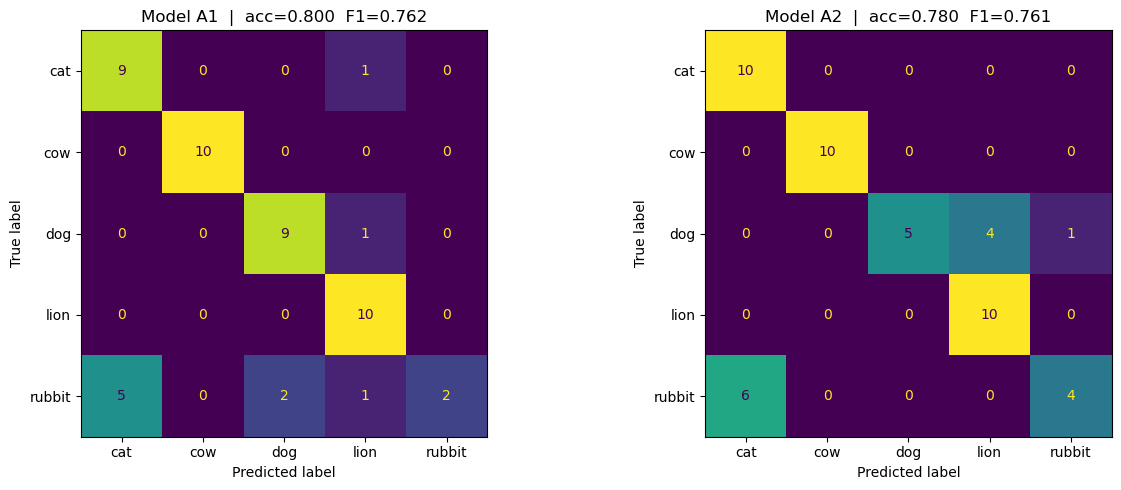

A1: accuracy 0.800, macro-F1 0.762
A2: accuracy 0.780, macro-F1 0.761


In [16]:
# ---- Confusion matrices, accuracy and macro-F1 ----
f1A1 = f1_score(labelsA1, predA1, average="macro")
f1A2 = f1_score(labelsA2, predA2, average="macro")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (preds, labels, name, acc, f1) in zip(
        axes,
        [(predA1, labelsA1, "A1", accA1, f1A1),
         (predA2, labelsA2, "A2", accA2, f1A2)]):
    cm = confusion_matrix(labels, preds)
    ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, colorbar=False)
    ax.set_title(f"Model {name}  |  acc={acc:.3f}  F1={f1:.3f}")
plt.tight_layout(); plt.show()

print(f"A1: accuracy {accA1:.3f}, macro-F1 {f1A1:.3f}")
print(f"A2: accuracy {accA2:.3f}, macro-F1 {f1A2:.3f}")


A2: 39 correct, 11 incorrect


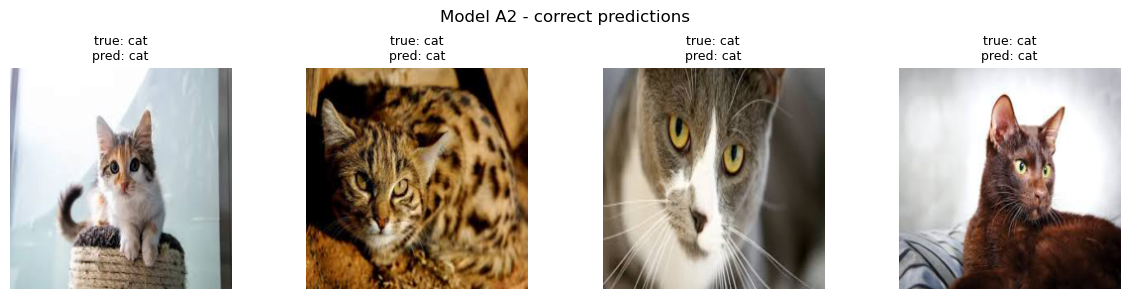

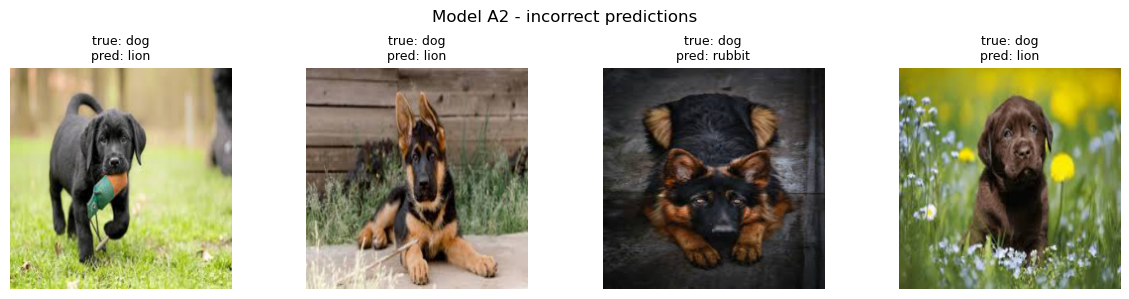

In [17]:
# ---- Visual examples: correct and incorrect predictions (Model A2) ----
@torch.no_grad()
def collect_examples(model, dataset, device=DEVICE):
    model.eval(); model.to(device)
    correct, wrong = [], []
    for img, lbl in dataset:
        pred = model(img.unsqueeze(0).to(device)).argmax(1).item()
        (correct if pred == lbl else wrong).append((img, lbl, pred))
    return correct, wrong

correct, wrong = collect_examples(modelA2, test_ds)
print(f"A2: {len(correct)} correct, {len(wrong)} incorrect")

def show_examples(items, title, k=4):
    if not items:
        print("No examples for:", title); return
    items = items[:k]
    fig, axes = plt.subplots(1, len(items), figsize=(3 * len(items), 3))
    if len(items) == 1: axes = [axes]
    for ax, (img, lbl, pred) in zip(axes, items):
        ax.imshow(denormalize(img).permute(1, 2, 0))
        ax.set_title(f"true: {CLASSES[lbl]}\npred: {CLASSES[pred]}", fontsize=9)
        ax.axis("off")
    plt.suptitle(title); plt.tight_layout(); plt.show()

show_examples(correct, "Model A2 - correct predictions")
show_examples(wrong,   "Model A2 - incorrect predictions")


### Part V — Discussion (answers for the report)

- **Did predictions change significantly?** Compare the two confusion matrices and the
  accuracy/F1 numbers above. Typically the difference after retraining is small.
- **Is the network robust to filter removal?** AlexNet's Conv2 contains redundant /
  correlated filters, so removing ~33% of the lowest-norm ones and retraining recovers
  most of the performance — the network is fairly robust to moderate pruning.
- **Trade-offs.** Pruning Conv2 gives only a *small parameter saving* (parameters are
  dominated by the fully-connected layers) but a *larger compute/FLOP saving* and faster
  CPU inference, possibly at the cost of a minor accuracy drop. The right operating point
  depends on the deployment constraints.

## Extra Credit — Innovation and Creativity

Two additional analyses: comparing filter-selection strategies and estimating FLOPs.

In [18]:
# ---- Extra credit 1: compare filter-selection strategies ----
# Built WITHOUT retraining to isolate how each strategy preserves the
# pretrained representation.
print("Selection strategy comparison (no retraining):")
for strat in ["l1", "l2", "random"]:
    m, _ = build_pruned_alexnet(modelA1, KEEP_CONV2, strategy=strat)
    acc, _, _ = evaluate(m, test_loader)
    print(f"  {strat:<7}: test accuracy {acc:.3f}")


Selection strategy comparison (no retraining):
  l1     : test accuracy 0.760
  l2     : test accuracy 0.800
  random : test accuracy 0.800


In [19]:
# ---- Extra credit 2: FLOPs estimate ----
def count_flops(model, img_size=IMG_SIZE):
    m = copy.deepcopy(model).cpu().eval()
    flops, hooks = {}, []
    def conv_hook(mod, i, o):
        flops[id(mod)] = (o.shape[1] * o.shape[2] * o.shape[3] *
                          mod.in_channels * mod.kernel_size[0] * mod.kernel_size[1] * 2)
    def lin_hook(mod, i, o):
        flops[id(mod)] = mod.in_features * mod.out_features * 2
    for mod in m.modules():
        if isinstance(mod, nn.Conv2d):
            hooks.append(mod.register_forward_hook(conv_hook))
        elif isinstance(mod, nn.Linear):
            hooks.append(mod.register_forward_hook(lin_hook))
    with torch.no_grad():
        m(torch.randn(1, 3, img_size, img_size))
    for h in hooks: h.remove()
    return sum(flops.values())

fA1, fA2 = count_flops(modelA1), count_flops(modelA2)
print(f"A1: {fA1/1e9:.3f} GFLOPs")
print(f"A2: {fA2/1e9:.3f} GFLOPs")
print(f"FLOPs reduction: {100*(fA1-fA2)/fA1:.2f}%")


A1: 1.420 GFLOPs
A2: 1.196 GFLOPs
FLOPs reduction: 15.78%


## Summary

- **A1** — original fine-tuned AlexNet.
- **A2** — pruned AlexNet (Conv2 reduced by ≥30%, Conv3 input channels adjusted, retrained
  with Conv1 + Conv2 frozen).
- Filter pruning on early convolutional layers yields a **modest parameter saving** but a
  **larger FLOP / inference-time saving**, with the network remaining robust to moderate
  pruning after retraining.

Remember to fill in the **dataset link** and **demonstration video link** at the top of
this notebook and in the report.